## **인장시험 및 압축시험 분석**

기계시스템공학실험(B) 고체생산 1주차

In [50]:
import pandas as pd
import warnings
warnings.filterwarnings(action = 'ignore')

al_result = pd.read_csv("D:/00 기계공학실험/고체 생산/TensTest_AL_B04_02.csv", encoding='euc-kr')
pl_result = pd.read_csv("D:/00 기계공학실험/고체 생산/TensTest_PL_B04_02.csv", encoding='euc-kr')

display(al_result.head())
display(pl_result.head())

,일련번호,시간,하중,변위,응력,변형율,진응력,진변형율
0,NaN,[sec],[kgf],[mm],[kgf/mm²],[%],[kgf/mm²],[%]
1,1.0,0,0,0,0,0,0,0
2,2.0,0,1,0,0.060606,0,0.060606,0
3,3.0,0.064,1,0.05,0.060606,0.083333,0.060657,0.080043
4,4.0,0.092,1.1,0.05,0.066667,0.083333,0.066722,0.080043


,일련번호,시간,하중,변위,응력,변형율,진응력,진변형율
0,NaN,[sec],[kgf],[mm],[kgf/mm²],[%],[kgf/mm²],[%]
1,1.0,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2.0,0.000,2.300000,0.000000,0.040266,0.000000,0.040266,0.000000
3,3.0,0.002,2.300000,0.030000,0.040266,0.050000,0.040286,0.048790
4,4.0,0.012,2.400000,0.030000,0.042017,0.050000,0.042038,0.048790


### **알루미늄 시편 분석**

알루미늄 시편에 대해 `matplotlib` 시각화 라이브러리를 사용하여 공칭 응력-변형률 선도를 그린다.

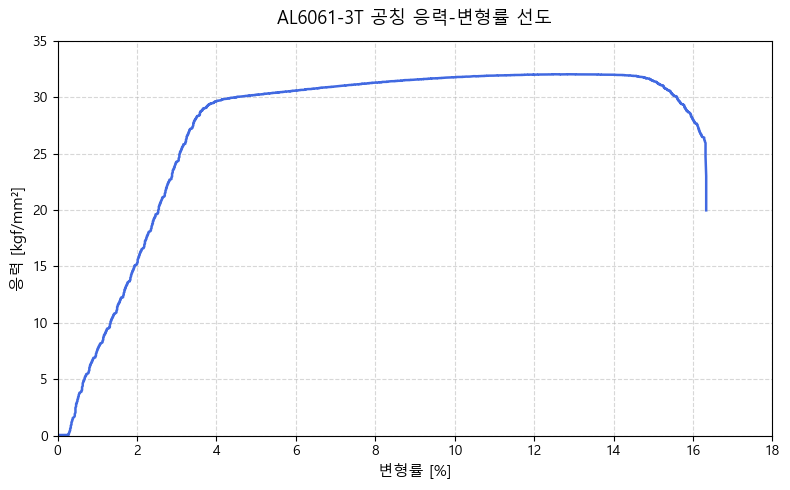

In [51]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 첫 번째 행에서 단위 정보 추출
stress_unit = al_result['응력'].iloc[0]
strain_unit = al_result['변형율'].iloc[0]

# 3. 두 번째 행(index 1)부터 데이터 슬라이싱 및 수치형(float) 변환
df_clean = al_result.iloc[1:].copy()
df_clean['응력'] = pd.to_numeric(df_clean['응력'])
df_clean['변형율'] = pd.to_numeric(df_clean['변형율'])

# 4. 선도 시각화
plt.figure(figsize=(8, 5), dpi=100)
plt.plot(df_clean['변형율'], df_clean['응력'], color='royalblue', linewidth=1.8, label='AL6061-3T')

plt.title('AL6061-3T 공칭 응력-변형률 선도', fontsize=13, pad=12)
plt.xlabel(f'변형률 {strain_unit}', fontsize=11)
plt.ylabel(f'응력 {stress_unit}', fontsize=11)
plt.ylim(0,35)
plt.xlim(0,18)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

세 점의 변형률: 10->1.3333%, 15->1.9333%, 20->2.5373%
계산된 영률(E): 8.3063 kgf/mm²/% (단위 환산: 8145.7 MPa)
0.2% Offset 항복변형률: 3.8743 %
0.2% Offset 항복강도: 29.4499 kgf/mm² (288.80 MPa)


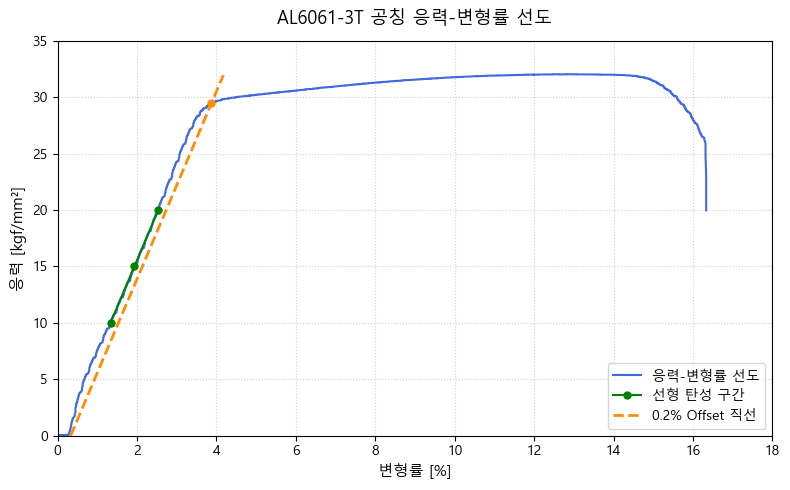

In [52]:
import numpy as np

df = al_result.iloc[1:].copy()
df['응력'] = pd.to_numeric(df['응력'])
df['변형율'] = pd.to_numeric(df['변형율'])

uts_idx = df['응력'].idxmax()           # 최대 응력
df_pre_uts = df.loc[:uts_idx].reset_index(drop=True)

## 선형탄성 구간 
target_stresses = np.array([10.0, 15.0, 20.0])
target_strains = np.interp(target_stresses, df_pre_uts['응력'], df_pre_uts['변형율'])
s1 = (target_stresses[1] - target_stresses[0]) / (target_strains[1] - target_strains[0])  # 10->15
s2 = (target_stresses[2] - target_stresses[1]) / (target_strains[2] - target_strains[1])  # 15->20
E = (s1 + s2) / 2  # 영률(E)
eps_0 = np.mean(target_strains) - np.mean(target_stresses) / E

print(f"세 점의 변형률: 10->{target_strains[0]:.4f}%, 15->{target_strains[1]:.4f}%, 20->{target_strains[2]:.4f}%")
print(f"계산된 영률(E): {E:.4f} kgf/mm²/% (단위 환산: {E * 100 * 9.80665:.1f} MPa)")

## 0.2 offset 게산과정
offset_delta = 0.2
eps_offset_origin = eps_0 + offset_delta    
diff = df_pre_uts['응력'] - E * (df_pre_uts['변형율'] - eps_offset_origin)      # offset 직선

sign_changes = np.where(np.diff(np.sign(diff)))[0]      # offset 직선과의 교점
valid_cross = [i for i in sign_changes if df_pre_uts.loc[i, '변형율'] >= 2.0][0]

x1, x2 = df_pre_uts.loc[valid_cross, '변형율'], df_pre_uts.loc[valid_cross + 1, '변형율']   # 항복점 파악
y1, y2 = df_pre_uts.loc[valid_cross, '응력'], df_pre_uts.loc[valid_cross + 1, '응력']
d1, d2 = diff[valid_cross], diff[valid_cross + 1]

t = -d1 / (d2 - d1)
yield_strain = x1 + t * (x2 - x1)
yield_stress = y1 + t * (y2 - y1)
print(f"0.2% Offset 항복변형률: {yield_strain:.4f} %")
print(f"0.2% Offset 항복강도: {yield_stress:.4f} kgf/mm² ({yield_stress * 9.80665:.2f} MPa)")

## 그래프 시각화
plt.figure(figsize=(8, 5), dpi=100)
plt.plot(df['변형율'], df['응력'], color='royalblue', linewidth=1.5, label='응력-변형률 선도')
plt.plot(target_strains, target_stresses, 'go-', linewidth=1.5, markersize=5, label=f'선형 탄성 구간')

stress_range = np.linspace(0, yield_stress + 2.5, 100)      # 0.2% offset
strain_offset_line = eps_offset_origin + stress_range / E
plt.plot(strain_offset_line, stress_range, color='darkorange', linestyle='--', linewidth=2, 
         label='0.2% Offset 직선')
plt.plot(yield_strain, yield_stress, 'o', color='darkorange', markersize=5)

plt.title('AL6061-3T 공칭 응력-변형률 선도', fontsize=13, pad=12)
plt.xlabel('변형률 [%]', fontsize=11)
plt.ylabel('응력 [kgf/mm²]', fontsize=11)
plt.xlim(0,18)  
plt.ylim(0,35)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()

plt.show()

인장강도: 32.03 kgf/mm² (단위 환산: 314.11 MPa)
파단강도: 19.97 kgf/mm² (단위 환산: 195.84 MPa)
파단 직전 지점 변형률: 16.33% (해당 지점 응력: 19.97 kgf/mm²)


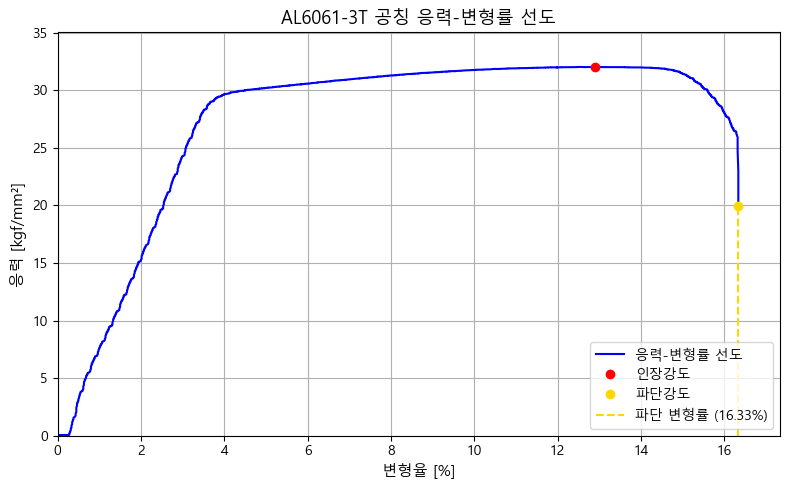

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

df = al_result.iloc[1:].copy()
df['응력'] = pd.to_numeric(df['응력'])
df['변형율'] = pd.to_numeric(df['변형율'])

# 인장강도
uts_idx = df['응력'].idxmax()
uts_stress = df.loc[uts_idx, '응력']
uts_strain = df.loc[uts_idx, '변형율']

## 파단강도 (데이터의 마지막 측정 지점 기준)
fracture_stress = df['응력'].iloc[-1]
fracture_strain = df['변형율'].iloc[-1]

print(f"인장강도: {uts_stress:.2f} kgf/mm² (단위 환산: {uts_stress * 9.80665:.2f} MPa)")
print(f"파단강도: {fracture_stress:.2f} kgf/mm² (단위 환산: {fracture_stress * 9.80665:.2f} MPa)")
print(f"파단 직전 지점 변형률: {fracture_strain:.2f}% (해당 지점 응력: {fracture_stress:.2f} kgf/mm²)")

## 그래프
plt.figure(figsize=(8, 5), dpi=100)
plt.plot(df['변형율'], df['응력'], color='blue', label='응력-변형률 선도')
plt.plot(uts_strain, uts_stress, 'ro', markersize=6, label='인장강도')
plt.plot(fracture_strain, fracture_stress, 'o', color='gold', markersize=6, label='파단강도')
plt.vlines(x=fracture_strain, ymin=0, ymax=fracture_stress, colors='gold', linestyles='--', label=f'파단 변형률 ({fracture_strain:.2f}%)')

plt.title('AL6061-3T 공칭 응력-변형률 선도', fontsize=13)
plt.xlabel('변형율 [%]', fontsize=11)
plt.ylabel('응력 [kgf/mm²]', fontsize=11)
plt.xlim(0, df['변형율'].max() + 1)
plt.ylim(0, df['응력'].max() + 3)
plt.grid(True)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

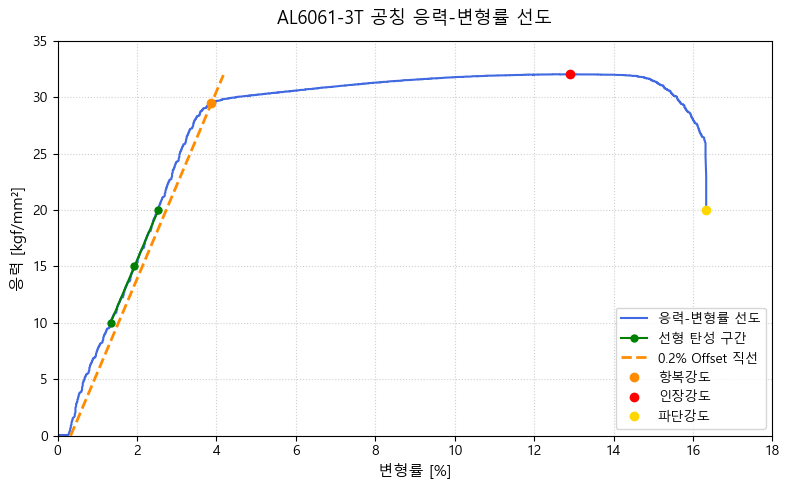

In [54]:
plt.figure(figsize=(8, 5), dpi=100)

# 1. 공칭 응력-변형률 선도
plt.plot(df['변형율'], df['응력'], color='royalblue', linewidth=1.5, label='응력-변형률 선도')

# 2. 선형 탄성 구간 세 점 연결선
plt.plot(target_strains, target_stresses, 'go-', linewidth=1.5, markersize=5, label='선형 탄성 구간')

# 3. 0.2% Offset 직선 및 항복점
plt.plot(strain_offset_line, stress_range, color='darkorange', linestyle='--', linewidth=2, label='0.2% Offset 직선')
plt.plot(yield_strain, yield_stress, 'o', color='darkorange', markersize=6, label='항복강도')

# 4. 인장강도 (빨간색 점)
plt.plot(uts_strain, uts_stress, 'ro', markersize=6, label='인장강도')

# 5. 파단강도 (초록색 점)
plt.plot(fracture_strain, fracture_stress, 'o',color='gold', markersize=6, label='파단강도')

# 그래프 서식 설정
plt.title('AL6061-3T 공칭 응력-변형률 선도', fontsize=13, pad=12)
plt.xlabel('변형률 [%]', fontsize=11)
plt.ylabel('응력 [kgf/mm²]', fontsize=11)
plt.xlim(0, 18)
plt.ylim(0, 35)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=9.5)
plt.tight_layout()

plt.show()

### **플라스틱 시편 분석**

플라스틱 시편에 대해 `matplotlib` 시각화 라이브러리를 사용하여 공칭 응력-변형률 선도를 그린다.

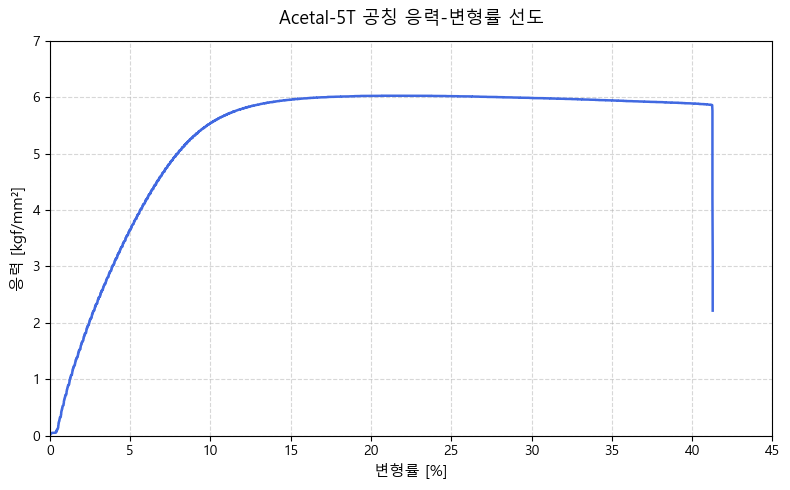

In [55]:
from matplotlib.ticker import MultipleLocator

stress_unit = pl_result['응력'].iloc[0]
strain_unit = pl_result['변형율'].iloc[0]

df_clean = pl_result.iloc[1:].copy()
df_clean['응력'] = pd.to_numeric(df_clean['응력'])
df_clean['변형율'] = pd.to_numeric(df_clean['변형율'])

## 그래프
plt.figure(figsize=(8, 5))
plt.plot(df_clean['변형율'], df_clean['응력'], color='royalblue', linewidth=1.8, label='Acetal-5T')

plt.title('Acetal-5T 공칭 응력-변형률 선도', fontsize=13, pad=12)
plt.xlabel(f'변형률 {strain_unit}', fontsize=11)
plt.ylabel(f'응력 {stress_unit}', fontsize=11)
plt.ylim(0,7)
plt.xlim(0,45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(5))
plt.tight_layout()

plt.show()

세 점의 변형률: 2->2.4500%, 3->3.8933%, 4->5.6333%
계산된 영률(E): 0.6338 kgf/mm²/% (단위 환산: 621.5 MPa)
0.2% Offset 항복변형률: 8.2626 %
0.2% Offset 항복강도: 5.1099 kgf/mm² (50.11 MPa)


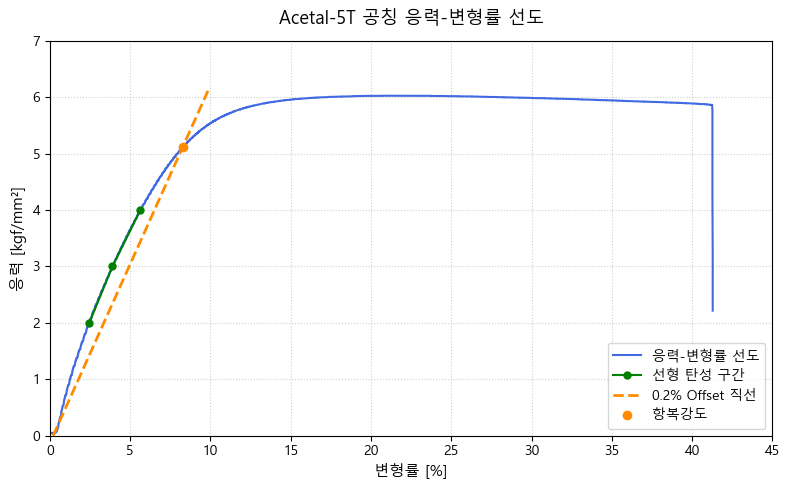

In [56]:
df = pl_result.iloc[1:].copy()
df['응력'] = pd.to_numeric(df['응력'])
df['변형율'] = pd.to_numeric(df['변형율'])

uts_idx = df['응력'].idxmax()           # 최대 응력
df_pre_uts = df.loc[:uts_idx].reset_index(drop=True)

## 선형탄성 구간 (2, 3, 4 kgf/mm²)
target_stresses = np.array([2.0, 3.0, 4.0])
target_strains = np.interp(target_stresses, df_pre_uts['응력'], df_pre_uts['변형율'])
s1 = (target_stresses[1] - target_stresses[0]) / (target_strains[1] - target_strains[0])  # 2->3
s2 = (target_stresses[2] - target_stresses[1]) / (target_strains[2] - target_strains[1])  # 3->4
E = (s1 + s2) / 2  # 영률(E)

print(f"세 점의 변형률: 2->{target_strains[0]:.4f}%, 3->{target_strains[1]:.4f}%, 4->{target_strains[2]:.4f}%")
print(f"계산된 영률(E): {E:.4f} kgf/mm²/% (단위 환산: {E * 100 * 9.80665:.1f} MPa)")

## 0.2% Offset 계산과정 ((0.2, 0)을 정확히 지나도록 수정)
eps_offset_origin = 0.2  # x절편을 0.2% 지점으로 직접 고정
diff = df_pre_uts['응력'] - E * (df_pre_uts['변형율'] - eps_offset_origin)  # offset 직선과의 응력차

# 탄성 영역 이후(변형률 2% 이상)에서 오프셋 직선과 만나는 교점 탐색
sign_changes = np.where(np.diff(np.sign(diff)))[0]
valid_cross = [i for i in sign_changes if df_pre_uts.loc[i, '변형율'] >= 2.0][0]

x1, x2 = df_pre_uts.loc[valid_cross, '변형율'], df_pre_uts.loc[valid_cross + 1, '변형율']
y1, y2 = df_pre_uts.loc[valid_cross, '응력'], df_pre_uts.loc[valid_cross + 1, '응력']
d1, d2 = diff[valid_cross], diff[valid_cross + 1]

t = -d1 / (d2 - d1)
yield_strain = x1 + t * (x2 - x1)
yield_stress = y1 + t * (y2 - y1)

print(f"0.2% Offset 항복변형률: {yield_strain:.4f} %")
print(f"0.2% Offset 항복강도: {yield_stress:.4f} kgf/mm² ({yield_stress * 9.80665:.2f} MPa)")

## 그래프 시각화
plt.figure(figsize=(8, 5), dpi=100)
plt.plot(df['변형율'], df['응력'], color='royalblue', linewidth=1.5, label='응력-변형률 선도')
plt.plot(target_strains, target_stresses, 'go-', linewidth=1.5, markersize=5, label='선형 탄성 구간')

# 0.2% offset 직선: (0.2, 0)에서 출발
stress_range = np.linspace(0, yield_stress + 1.0, 100)
strain_offset_line = eps_offset_origin + stress_range / E
plt.plot(strain_offset_line, stress_range, color='darkorange', linestyle='--', linewidth=2, 
         label='0.2% Offset 직선')
plt.plot(yield_strain, yield_stress, 'o', color='darkorange', markersize=6, 
         label=f'항복강도')

plt.title('Acetal-5T 공칭 응력-변형률 선도', fontsize=13, pad=12)
plt.xlabel('변형률 [%]', fontsize=11)
plt.ylabel('응력 [kgf/mm²]', fontsize=11)
plt.xlim(0, 45)  # 항복 거동이 뚜렷하게 보이도록 범위 설정 (필요시 45로 변경)
plt.ylim(0, 7)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()

plt.show()

인장강도: 6.03 kgf/mm² (단위 환산: 59.09 MPa)
파단강도: 5.76 kgf/mm² (단위 환산: 56.45 MPa)
파단 직전 지점 변형률: 41.27% (해당 지점 응력: 5.76 kgf/mm²)


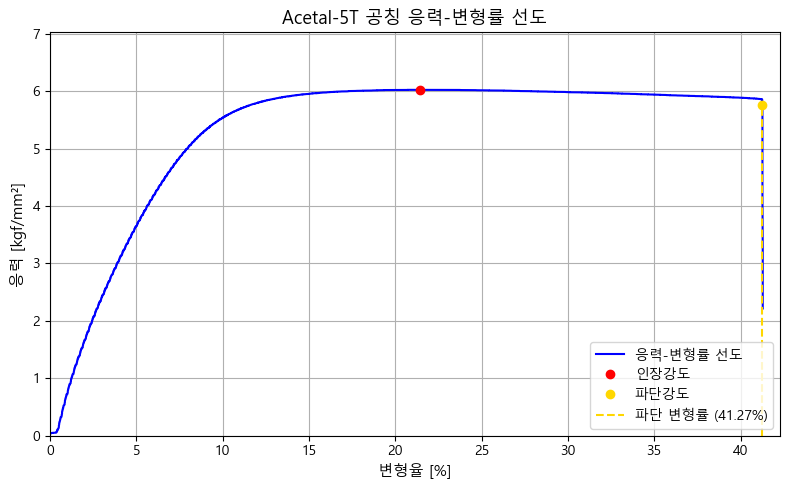

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

df = pl_result.iloc[1:].copy()
df['응력'] = pd.to_numeric(df['응력'])
df['변형율'] = pd.to_numeric(df['변형율'])

# 인장강도
uts_idx = df['응력'].idxmax()
uts_stress = df.loc[uts_idx, '응력']
uts_strain = df.loc[uts_idx, '변형율']

## 파단강도
stress_diff = df['응력'].diff()
drop_idx = df[stress_diff < -0.2].index[0]
pre_drop_idx = drop_idx - 1

fracture_stress = df.loc[pre_drop_idx, '응력']
fracture_strain = df.loc[pre_drop_idx, '변형율']

print(f"인장강도: {uts_stress:.2f} kgf/mm² (단위 환산: {uts_stress * 9.80665:.2f} MPa)")
print(f"파단강도: {fracture_stress:.2f} kgf/mm² (단위 환산: {fracture_stress * 9.80665:.2f} MPa)")
print(f"파단 직전 지점 변형률: {fracture_strain:.2f}% (해당 지점 응력: {fracture_stress:.2f} kgf/mm²)")

## 그래프
plt.figure(figsize=(8, 5), dpi=100)
plt.plot(df['변형율'], df['응력'], color='blue', label='응력-변형률 선도')
plt.plot(uts_strain, uts_stress, 'ro', markersize=6, label='인장강도')
plt.plot(fracture_strain, fracture_stress, 'o', color='gold', markersize=6, label='파단강도')
plt.vlines(x=fracture_strain, ymin=0, ymax=fracture_stress, colors='gold', linestyles='--', label=f'파단 변형률 ({fracture_strain:.2f}%)')

plt.title('Acetal-5T 공칭 응력-변형률 선도', fontsize=13)
plt.xlabel('변형율 [%]', fontsize=11)
plt.ylabel('응력 [kgf/mm²]', fontsize=11)
plt.xlim(0, df['변형율'].max() + 1)
plt.ylim(0, df['응력'].max() + 1)
plt.grid(True)
plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

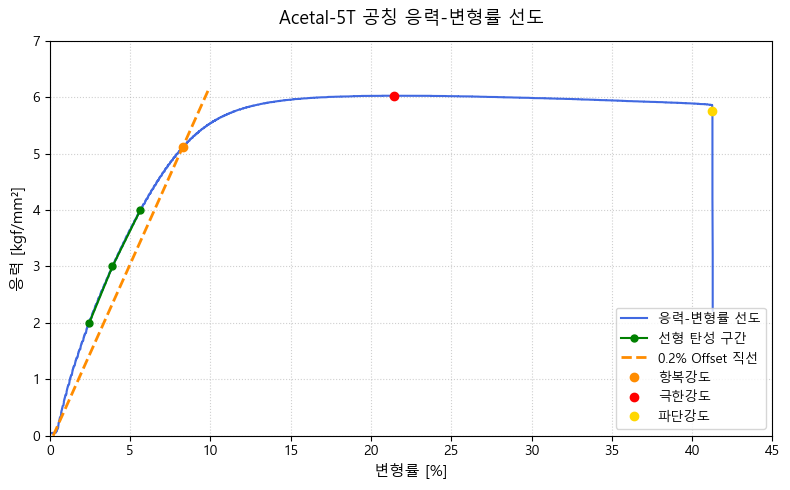

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -------------------------------------------------------------
# 1. 데이터 전처리 및 좌표 계산 (Acetal-5T)
# -------------------------------------------------------------
df = pl_result.iloc[1:].copy()
df['응력'] = pd.to_numeric(df['응력'])
df['변형율'] = pd.to_numeric(df['변형율'])

# 인장강도 (UTS)
uts_idx = df['응력'].idxmax()
uts_stress, uts_strain = df.loc[uts_idx, '응력'], df.loc[uts_idx, '변형율']
df_pre_uts = df.loc[:uts_idx].reset_index(drop=True)

# 선형 탄성 구간 (2, 3, 4 kgf/mm²)
target_stresses = np.array([2.0, 3.0, 4.0])
target_strains = np.interp(target_stresses, df_pre_uts['응력'], df_pre_uts['변형율'])
s1 = (target_stresses[1] - target_stresses[0]) / (target_strains[1] - target_strains[0])
s2 = (target_stresses[2] - target_stresses[1]) / (target_strains[2] - target_strains[1])
E = (s1 + s2) / 2

# 0.2% Offset 직선 및 항복강도 ((0.2, 0)을 지나는 직선)
eps_offset_origin = 0.2
diff = df_pre_uts['응력'] - E * (df_pre_uts['변형율'] - eps_offset_origin)
valid_cross = [i for i in np.where(np.diff(np.sign(diff)))[0] if df_pre_uts.loc[i, '변형율'] >= 2.0][0]

t = -diff[valid_cross] / (diff[valid_cross + 1] - diff[valid_cross])
yield_strain = df_pre_uts.loc[valid_cross, '변형율'] + t * (df_pre_uts.loc[valid_cross + 1, '변형율'] - df_pre_uts.loc[valid_cross, '변형율'])
yield_stress = df_pre_uts.loc[valid_cross, '응력'] + t * (df_pre_uts.loc[valid_cross + 1, '응력'] - df_pre_uts.loc[valid_cross, '응력'])

stress_range = np.linspace(0, yield_stress + 1.0, 100)
strain_offset_line = eps_offset_origin + stress_range / E

# 파단강도 (급격한 감소 직전 지점)
stress_diff = df['응력'].diff()
pre_drop_idx = df[stress_diff < -0.2].index[0] - 1
fracture_stress, fracture_strain = df.loc[pre_drop_idx, '응력'], df.loc[pre_drop_idx, '변형율']

# -------------------------------------------------------------
# 2. Acetal-5T 전용 시각화
# -------------------------------------------------------------
plt.figure(figsize=(8, 5), dpi=100)

# 1. 공칭 응력-변형률 선도
plt.plot(df['변형율'], df['응력'], color='royalblue', linewidth=1.5, label='응력-변형률 선도')

# 2. 선형 탄성 구간 세 점 연결선
plt.plot(target_strains, target_stresses, 'go-', linewidth=1.5, markersize=5, label='선형 탄성 구간')

# 3. 0.2% Offset 직선 및 항복점
plt.plot(strain_offset_line, stress_range, color='darkorange', linestyle='--', linewidth=2, label='0.2% Offset 직선')
plt.plot(yield_strain, yield_stress, 'o', color='darkorange', markersize=6, label='항복강도')

# 4. 인장강도 (빨간색 점)
plt.plot(uts_strain, uts_stress, 'ro', markersize=6, label='극한강도')

# 5. 파단강도 (골드색 점)
plt.plot(fracture_strain, fracture_stress, 'o', color='gold', markersize=6, label='파단강도')

# 그래프 서식 설정 (Acetal-5T 물성 범위 반영)
plt.title('Acetal-5T 공칭 응력-변형률 선도', fontsize=13, pad=12)
plt.xlabel('변형률 [%]', fontsize=11)
plt.ylabel('응력 [kgf/mm²]', fontsize=11)
plt.xlim(0, 45)  # Acetal의 파단 연신율(~41%)을 고려해 45까지 확장
plt.ylim(0, 7)   # 최대 응력(~6.03 kgf/mm²)에 맞춰 7까지 설정
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=9.5)
plt.tight_layout()

plt.show()

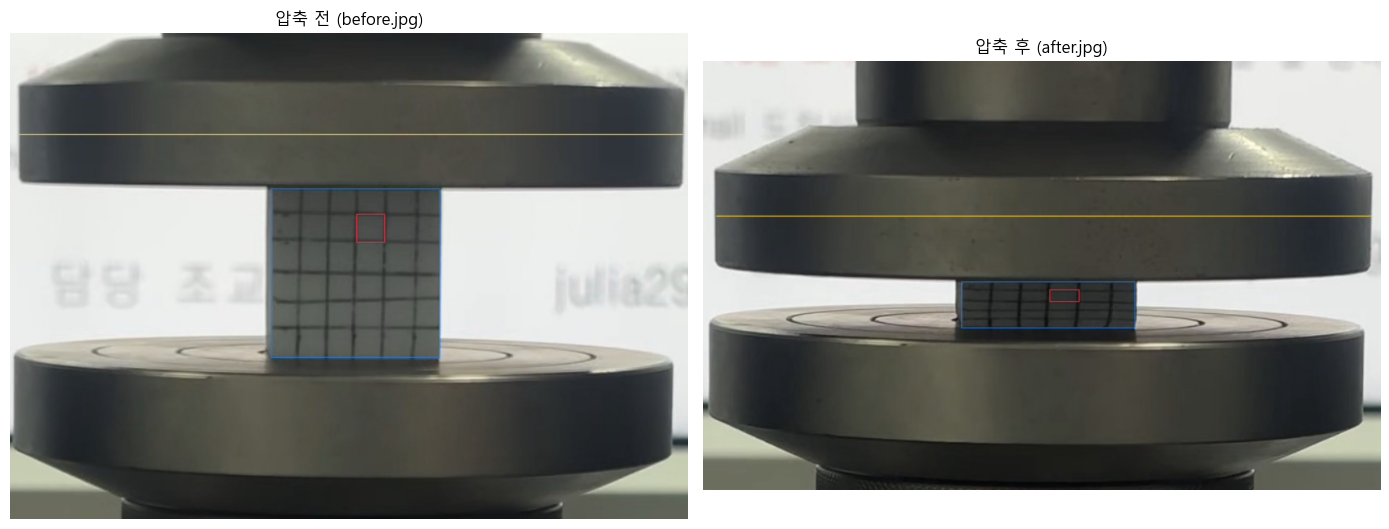

In [59]:
import cv2
import matplotlib.pyplot as plt
import platform
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 이미지 로드 (OpenCV는 BGR 형태로 로드)
img_before_bgr = cv2.imread('before.jpg')
img_after_bgr = cv2.imread('after.jpg')

# 파일 정상 로드 확인
if img_before_bgr is None or img_after_bgr is None:
    raise FileNotFoundError("이미지 파일을 찾을 수 없습니다. 경로와 파일명을 확인해 주세요.")

# 2. Matplotlib 출력을 위한 BGR -> RGB 색상 변환
img_before = cv2.cvtColor(img_before_bgr, cv2.COLOR_BGR2RGB)
img_after = cv2.cvtColor(img_after_bgr, cv2.COLOR_BGR2RGB)

# 3. 나란히 시각화
plt.figure(figsize=(14, 6), dpi=100)

plt.subplot(1, 2, 1)
plt.imshow(img_before)
plt.title('압축 전 (before.jpg)', fontsize=12)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_after)
plt.title('압축 후 (after.jpg)', fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

In [60]:
import cv2
import numpy as np

def measure_shapes(img_bgr):
    """
    이미지 내 노란색 선, 빨간색 사각형, 파란색 사각형의 픽셀 치수를 추출하는 함수
    """
    # 1. BGR -> HSV 색상 공간 변환 (색상 분리에 유리)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h_img = img_bgr.shape[0]

    # -------------------------------------------------------------
    # 1. 노란색 선 (상부 압축판 기준선)
    # -------------------------------------------------------------
    # 노란색 색상 범위 (H: 15~35)
    mask_yellow = cv2.inRange(hsv, (15, 40, 100), (35, 255, 255))
    y_pts = np.column_stack(np.where(mask_yellow > 0))  # [y, x] 좌표
    
    # 상부 압축판 위치(이미지 상단 50% 영역) 필터링
    y_pts_upper = y_pts[y_pts[:, 0] < h_img * 0.5]
    if len(y_pts_upper) > 0:
        yellow_len = int(np.max(y_pts_upper[:, 1]) - np.min(y_pts_upper[:, 1]))
    else:
        yellow_len = 0

    # -------------------------------------------------------------
    # 2. 빨간색 직사각형 (단위 격자)
    # -------------------------------------------------------------
    # 빨간색은 Hue 축의 양 끝(0~10, 170~180)에 걸쳐 있으므로 두 영역을 합침
    mask_red1 = cv2.inRange(hsv, (0, 70, 70), (10, 255, 255))
    mask_red2 = cv2.inRange(hsv, (170, 70, 70), (180, 255, 255))
    mask_red = cv2.bitwise_or(mask_red1, mask_red2)

    cnts_r, _ = cv2.findContours(mask_red, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # 최소 크기(너비 15px 이상) 이상의 윤곽선 중 가장 큰 외곽 사각형 검출
    valid_r = [cv2.boundingRect(c) for c in cnts_r if cv2.boundingRect(c)[2] >= 15]
    if valid_r:
        best_r = max(valid_r, key=lambda b: b[2] * b[3])
        red_w, red_h = best_r[2], best_r[3]
    else:
        red_w, red_h = 0, 0

    # -------------------------------------------------------------
    # 3. 파란색 직사각형 (시편 전체 영역)
    # -------------------------------------------------------------
    # 파란색 색상 범위 (H: 95~125)
    mask_blue = cv2.inRange(hsv, (95, 70, 70), (125, 255, 255))
    cnts_b, _ = cv2.findContours(mask_blue, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 시편 전체 윤곽선(너비 50px 이상) 중 가장 큰 외곽 사각형 검출
    valid_b = [cv2.boundingRect(c) for c in cnts_b if cv2.boundingRect(c)[2] >= 50]
    if valid_b:
        best_b = max(valid_b, key=lambda b: b[2] * b[3])
        blue_w, blue_h = best_b[2], best_b[3]
    else:
        blue_w, blue_h = 0, 0

    return {
        'yellow_len': yellow_len,
        'red_w': red_w,
        'red_h': red_h,
        'blue_w': blue_w,
        'blue_h': blue_h
    }

# 이전 단계에서 불러온 img_before_bgr, img_after_bgr 적용
meas_before = measure_shapes(img_before_bgr)
meas_after = measure_shapes(img_after_bgr)

# 결과 출력
print("=" * 45)
print(" [압축 전 이미지 (before.jpg) 픽셀 측정값]")
print(f"시험기 가압판 지름       | {meas_before['yellow_len']} px")
print(f"폼 큐브 격자 (가로x세로) | {meas_before['red_w']} px x {meas_before['red_h']} px")
print(f"폼 큐브 전체 (가로x세로) | {meas_before['blue_w']} px x {meas_before['blue_h']} px")
print("=" * 45)
print(" [압축 후 이미지 (after.jpg) 픽셀 측정값]")
print(f"시험기 가압판 지름       | {meas_after['yellow_len']} px")
print(f"폼 큐브 격자 (가로x세로) | {meas_after['red_w']} px x {meas_after['red_h']} px")
print(f"폼 큐브 전체 (가로x세로) | {meas_after['blue_w']} px x {meas_after['blue_h']} px")
print("=" * 45)

 [압축 전 이미지 (before.jpg) 픽셀 측정값]
시험기 가압판 지름       | 809 px
폼 큐브 격자 (가로x세로) | 38 px x 38 px
폼 큐브 전체 (가로x세로) | 209 px x 210 px
 [압축 후 이미지 (after.jpg) 픽셀 측정값]
시험기 가압판 지름       | 810 px
폼 큐브 격자 (가로x세로) | 40 px x 18 px
폼 큐브 전체 (가로x세로) | 216 px x 61 px


In [61]:
# 1. 압축 전 이미지 스케일 계산 (빨간색 가로 길이 = 5 mm)
red_w_pre = meas_before['red_w']
scale_pre = 5.0 / red_w_pre

# 2. 압축 후 이미지 스케일 계산 (노란색 선의 실제 길이가 동일하다고 가정)
yellow_len_pre = meas_before['yellow_len']
yellow_len_post = meas_after['yellow_len']

# 노란색 선의 실제 물리적 길이 (mm)
yellow_actual_mm = yellow_len_pre * scale_pre

# 압축 후 스케일 (mm/pixel)
scale_post = yellow_actual_mm / yellow_len_post

# 3. 유효숫자 4개 출력 (포맷 지정자 :.4g 사용)
print(f"압축 전 이미지 스케일 | {scale_pre:.4g} mm/pixel")
print(f"시험기 가압판 지름    | {yellow_actual_mm:.4g} mm")
print(f"압축 후 이미지 스케일 | {scale_post:.4g} mm/pixel")

압축 전 이미지 스케일 | 0.1316 mm/pixel
시험기 가압판 지름    | 106.4 mm
압축 후 이미지 스케일 | 0.1314 mm/pixel


In [62]:
# 1. 압축 전/후 이미지 스케일(mm/pixel) 계산
scale_pre = 5.0 / meas_before['red_w']
yellow_actual_mm = meas_before['yellow_len'] * scale_pre
scale_post = yellow_actual_mm / meas_after['yellow_len']

# 2. mm 단위 환산 결과 출력
print("=" * 45)
print(" [압축 전 이미지 (before.jpg) 실제 치수]")
print(f"시험기 가압판 지름       | {meas_before['yellow_len'] * scale_pre:.2f} mm")
print(f"폼 큐브 격자 (가로x세로) | {meas_before['red_w'] * scale_pre:.2f} mm x {meas_before['red_h'] * scale_pre:.2f} mm")
print(f"폼 큐브 전체 (가로x세로) | {meas_before['blue_w'] * scale_pre:.2f} mm x {meas_before['blue_h'] * scale_pre:.2f} mm")
print("=" * 45)
print(" [압축 후 이미지 (after.jpg) 실제 치수]")
print(f"시험기 가압판 지름       | {meas_after['yellow_len'] * scale_post:.2f} mm")
print(f"폼 큐브 격자 (가로x세로) | {meas_after['red_w'] * scale_post:.2f} mm x {meas_after['red_h'] * scale_post:.2f} mm")
print(f"폼 큐브 전체 (가로x세로) | {meas_after['blue_w'] * scale_post:.2f} mm x {meas_after['blue_h'] * scale_post:.2f} mm")
print("=" * 45)

 [압축 전 이미지 (before.jpg) 실제 치수]
시험기 가압판 지름       | 106.45 mm
폼 큐브 격자 (가로x세로) | 5.00 mm x 5.00 mm
폼 큐브 전체 (가로x세로) | 27.50 mm x 27.63 mm
 [압축 후 이미지 (after.jpg) 실제 치수]
시험기 가압판 지름       | 106.45 mm
폼 큐브 격자 (가로x세로) | 5.26 mm x 2.37 mm
폼 큐브 전체 (가로x세로) | 28.39 mm x 8.02 mm
